In [10]:
!pip install yfinance

In [11]:
import yfinance as yf

In [12]:
df_tsla = yf.download("TSLA", start= "2025-01-01", end = "2025-12-14")

/tmp/ipykernel_2073/1307915602.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_tsla = yf.download("TSLA", start= "2025-01-01", end = "2025-12-14")
[*********************100%***********************]  1 of 1 completed


In [13]:
df_tsla.head(5)

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2025-01-02,379.279999,392.730011,373.040009,390.100006,109710700
2025-01-03,410.440002,411.880005,379.450012,381.480011,95423300
2025-01-06,411.049988,426.429993,401.700012,423.200012,85516500
2025-01-07,394.359985,414.329987,390.000000,405.829987,75699500
2025-01-08,394.940002,402.500000,387.399994,392.950012,73038800


In [14]:
df_tsla.tail(5)

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2025-12-08,439.579987,449.750000,435.250000,447.450012,69165800
2025-12-09,445.170013,452.390015,435.700012,437.540009,62367400
2025-12-10,451.450012,456.880005,443.609985,446.070007,63257500
2025-12-11,446.890015,449.269989,440.329987,448.950012,55979500
2025-12-12,458.959991,463.010010,441.670013,448.089996,95656700


In [15]:
df_tsla.columns = ['_'.join(col).strip() for col in df_tsla.columns.values]

In [16]:
df_tsla.head(5)

,Close_TSLA,High_TSLA,Low_TSLA,Open_TSLA,Volume_TSLA
Date,,,,,
2025-01-02,379.279999,392.730011,373.040009,390.100006,109710700
2025-01-03,410.440002,411.880005,379.450012,381.480011,95423300
2025-01-06,411.049988,426.429993,401.700012,423.200012,85516500
2025-01-07,394.359985,414.329987,390.000000,405.829987,75699500
2025-01-08,394.940002,402.500000,387.399994,392.950012,73038800


In [17]:
df_tsla.describe()

,Close_TSLA,High_TSLA,Low_TSLA,Open_TSLA,Volume_TSLA
count,238.000000,238.000000,238.000000,238.000000,2.380000e+02
mean,351.037815,358.787437,342.706135,350.956513,9.864387e+07
std,66.328747,66.547889,65.975187,66.495470,3.467829e+07
min,221.860001,230.100006,214.250000,223.779999,3.625290e+07
25%,303.424988,310.232498,297.392502,306.629997,7.571682e+07
50%,340.654999,348.384995,333.349991,343.100006,9.313230e+07
75%,413.737503,425.400009,405.907509,415.982498,1.126000e+08
max,468.369995,474.070007,453.799988,470.540009,2.874998e+08


Tesla's closing price varied significantly during the observed period, ranging from approximately $222 to $468.

In [18]:
df_tsla.isnull().sum()

,0
Close_TSLA,0
High_TSLA,0
Low_TSLA,0
Open_TSLA,0
Volume_TSLA,0


No missing values were found in the dataset, indicating that the stock price records are complete and suitable for analysis without imputation.

In [19]:
df_tsla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 238 entries, 2025-01-02 to 2025-12-12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close_TSLA   238 non-null    float64
 1   High_TSLA    238 non-null    float64
 2   Low_TSLA     238 non-null    float64
 3   Open_TSLA    238 non-null    float64
 4   Volume_TSLA  238 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.2 KB


The Tesla dataset contains 238 observations and 5 features representing daily stock prices and trading volume. All variables have appropriate data types for analysis.

In [22]:
corr = df_tsla.corr()

print(corr)

             Close_TSLA  High_TSLA  Low_TSLA  Open_TSLA  Volume_TSLA
Close_TSLA     1.000000   0.994624  0.994751   0.986455    -0.466386
High_TSLA      0.994624   1.000000  0.993826   0.994126    -0.433499
Low_TSLA       0.994751   0.993826  1.000000   0.993788    -0.506186
Open_TSLA      0.986455   0.994126  0.993788   1.000000    -0.471343
Volume_TSLA   -0.466386  -0.433499 -0.506186  -0.471343     1.000000


Correlation analysis revealed a very strong positive relationship among Tesla's price variables (Open, High, Low, and Close), with correlation coefficients exceeding 0.98. This indicates that the stock price metrics move together consistently over time. Trading volume exhibited a moderate negative correlation with price variables, suggesting that periods of higher trading activity often coincided with relatively lower stock prices during the observed period.

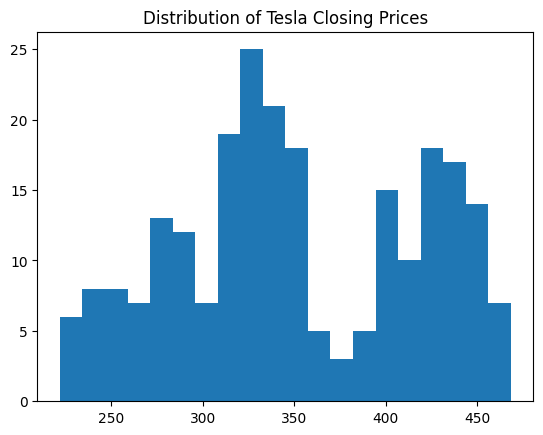

In [23]:
plt.hist(df_tsla['Close_TSLA'], bins=20)
plt.title("Distribution of Tesla Closing Prices")
plt.show()

## Findings

 Tesla closing prices ranged from approximately 220 to 470 during the analysis period. Most observations were concentrated between 300 and 350. A second concentration of prices was observed between 410 and 450 indicating periods of higher stock valuation.The distribution is not perfectly normal and reflects fluctuations in Tesla's market performance over time.The histogram suggests that Tesla experienced multiple price levels throughout the observed period.

In [24]:
from scipy.stats import zscore

df_tsla['Z_Score'] = zscore(df_tsla['Close_TSLA'])

Z-Score is calculated using Tesla closing prices.
Z-Score measures how far a stock price deviates from the average closing price.Positive values indicate prices above average, while negative values indicate prices below average.

In [25]:
df_tsla.head()

,Close_TSLA,High_TSLA,Low_TSLA,Open_TSLA,Volume_TSLA,Z_Score
Date,,,,,,
2025-01-02,379.279999,392.730011,373.040009,390.100006,109710700,0.426688
2025-01-03,410.440002,411.880005,379.450012,381.480011,95423300,0.897460
2025-01-06,411.049988,426.429993,401.700012,423.200012,85516500,0.906675
2025-01-07,394.359985,414.329987,390.000000,405.829987,75699500,0.654520
2025-01-08,394.940002,402.500000,387.399994,392.950012,73038800,0.663283


In [26]:
def risk_class(z):
    if z < -1:
        return 'Low'
    elif z > 1:
        return 'High'
    else:
        return 'Medium'

df_tsla['Risk_Class'] = df_tsla['Z_Score'].apply(risk_class)

In [27]:
print(df_tsla['Risk_Class'].value_counts())

Risk_Class
Medium    136
High       57
Low        45
Name: count, dtype: int64


Medium Risk observations were the most common with 136 records.
- High Risk observations accounted for 57 records.
- Low Risk observations accounted for 45 records.
- The dataset is moderately balanced and suitable for classification modeling.

In [28]:
df_tsla['Target'] = df_tsla['Risk_Class'].shift(-1)

In [67]:
df_tsla.head(10)

,Close_TSLA,High_TSLA,Low_TSLA,Open_TSLA,Volume_TSLA,Z_Score,Risk_Class,Target
Date,,,,,,,,
2025-01-02,379.279999,392.730011,373.040009,390.100006,109710700,0.426688,Medium,Medium
2025-01-03,410.440002,411.880005,379.450012,381.480011,95423300,0.897460,Medium,Medium
2025-01-06,411.049988,426.429993,401.700012,423.200012,85516500,0.906675,Medium,Medium
2025-01-07,394.359985,414.329987,390.000000,405.829987,75699500,0.654520,Medium,Medium
2025-01-08,394.940002,402.500000,387.399994,392.950012,73038800,0.663283,Medium,Medium
2025-01-10,394.739990,399.279999,377.290009,391.399994,62287300,0.660261,Medium,Medium
2025-01-13,403.309998,403.790009,380.070007,383.209991,67580500,0.789738,Medium,Medium
2025-01-14,396.359985,422.640015,394.540009,414.339996,84565000,0.684736,Medium,High
2025-01-15,428.220001,429.799988,405.660004,409.899994,81375500,1.166083,High,Medium


The target variable was created by shifting the Risk Class column by one day. The objective is to predict tomorrow's risk category using today's stock information.This transforms the problem into a supervised classification task.

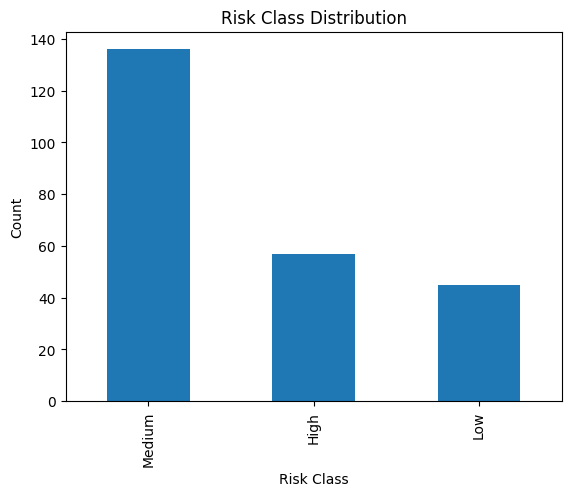

In [30]:
import matplotlib.pyplot as plt

df_tsla['Risk_Class'].value_counts().plot(kind='bar')

plt.title('Risk Class Distribution')
plt.xlabel('Risk Class')
plt.ylabel('Count')

plt.show()

In [34]:
print(df_tsla['Target'].value_counts())

Target
Medium    135
High       57
Low        45
Name: count, dtype: int64


## **Feature Selection**

In [35]:
X = df_tsla[['Close_TSLA',	'High_TSLA', 'Low_TSLA',	'Open_TSLA',	'Volume_TSLA',	'Z_Score']]

In [36]:
y = df_tsla['Target']

In [37]:
print(X.head())


            Close_TSLA   High_TSLA    Low_TSLA   Open_TSLA  Volume_TSLA  \
Date                                                                      
2025-01-02  379.279999  392.730011  373.040009  390.100006    109710700   
2025-01-03  410.440002  411.880005  379.450012  381.480011     95423300   
2025-01-06  411.049988  426.429993  401.700012  423.200012     85516500   
2025-01-07  394.359985  414.329987  390.000000  405.829987     75699500   
2025-01-08  394.940002  402.500000  387.399994  392.950012     73038800   

             Z_Score  
Date                  
2025-01-02  0.426688  
2025-01-03  0.897460  
2025-01-06  0.906675  
2025-01-07  0.654520  
2025-01-08  0.663283  


In [38]:
print(y.head())

Date
2025-01-02    Medium
2025-01-03    Medium
2025-01-06    Medium
2025-01-07    Medium
2025-01-08    Medium
Name: Target, dtype: object


# Label Encoding

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [40]:
print(le.classes_)

['High' 'Low' 'Medium']


In [41]:
print(y[:10])

[2 2 2 2 2 2 2 0 2 0]


Machine learning algorithms require numerical labels. Risk categories were converted into numerical values using Label Encoding. The encoded values allow classification algorithms to process the target variable.

# Train-Test Split

In [42]:

from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [44]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(189, 6)
(48, 6)
(189,)
(48,)


The dataset was divided into 80% training data and 20% testing data. Training data was used for learning patterns. Testing data was used to evaluate model performance on unseen observations.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [46]:
print(X_train_scaled[:5])

[[ 1.39540042  1.27324954  1.22751075  1.1978222   0.03001926  1.39540042]
 [ 1.37365807  1.35026074  1.34893404  1.42638742 -0.45823798  1.37365807]
 [ 1.491797    1.38641198  1.38103943  1.25515227 -0.36229054  1.491797  ]
 [-0.21293328 -0.14120257 -0.12396779 -0.06750671  0.05017114 -0.21293328]
 [ 1.28425544  1.45871398  1.40142918  1.49231661  0.04854312  1.28425544]]


Feature scaling was applied using StandardScaler. Scaling ensures all variables contribute equally during model training. Scaling is particularly important for KNN and SVM algorithms.

# KNN

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [48]:
y_pred_knn = knn.predict(X_test_scaled)

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

Accuracy: 0.8958333333333334
[[11  0  1]
 [ 0  7  1]
 [ 2  1 25]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.88      0.88      0.88         8
           2       0.93      0.89      0.91        28

    accuracy                           0.90        48
   macro avg       0.88      0.89      0.89        48
weighted avg       0.90      0.90      0.90        48



The KNN classifier achieved an accuracy of 89.58% on the test dataset. The model demonstrated strong performance across all three risk classes, with F1-scores ranging from 0.88 to 0.91. Medium Risk was predicted most accurately, while High and Low Risk classes also showed strong recall and precision values.

# Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)



In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8541666666666666
[[10  0  2]
 [ 0  6  2]
 [ 3  0 25]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        12
           1       1.00      0.75      0.86         8
           2       0.86      0.89      0.88        28

    accuracy                           0.85        48
   macro avg       0.88      0.83      0.84        48
weighted avg       0.86      0.85      0.85        48



The Decision Tree classifier achieved an accuracy of 85.42%. The model showed strong performance in predicting Medium Risk observations, while Low Risk observations had relatively lower recall. Compared with KNN, the Decision Tree produced slightly lower overall accuracy.

# SVM

In [52]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9166666666666666
[[12  0  0]
 [ 0  5  3]
 [ 0  1 27]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.62      0.71         8
           2       0.90      0.96      0.93        28

    accuracy                           0.92        48
   macro avg       0.91      0.86      0.88        48
weighted avg       0.91      0.92      0.91        48



The SVM classifier achieved the highest accuracy of 91.67% among the evaluated models. The model perfectly classified all High Risk observations and achieved strong performance for Medium Risk observations. Although the recall for Low Risk observations was comparatively lower, SVM provided the best overall predictive performance.

# Ramdom Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8958333333333334
[[10  0  2]
 [ 0  6  2]
 [ 0  1 27]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.86      0.75      0.80         8
           2       0.87      0.96      0.92        28

    accuracy                           0.90        48
   macro avg       0.91      0.85      0.87        48
weighted avg       0.90      0.90      0.89        48



Four machine learning models were developed and evaluated to predict the next day's stock risk class (High, Medium, or Low) based on Tesla stock market data. Risk classes were created using Z-score analysis of the closing prices. The models evaluated were K-Nearest Neighbors (KNN), Decision Tree, Support Vector Machine (SVM), and Random Forest.

Among all models, SVM achieved the highest accuracy of 91.67%, followed by KNN and Random Forest with 89.58%, while Decision Tree achieved 85.42%. Based on the evaluation results, SVM was selected as the final model because it demonstrated the strongest predictive performance and the lowest classification error.

The developed model can be used to predict the risk category of future Tesla stock observations and support data-driven investment risk assessment.


In [70]:
last_day = X.iloc[[-1]]

last_day_scaled = scaler.transform(last_day)

prediction = svm.predict(last_day_scaled)

risk_class = le.inverse_transform(prediction)

print("Next Day Predicted Risk Class:", risk_class[0])

Next Day Predicted Risk Class: High


The trained SVM model successfully predicted the next day's Tesla stock risk category. The saved model can be reused for future predictions. This demonstrates the practical applicability of machine learning for stock risk assessment.

In [71]:
import joblib

joblib.dump(svm, 'tesla_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [57]:
!ls

label_encoder.pkl  sample_data	scaler.pkl  tesla_risk_model.pkl


In [74]:
from google.colab import files

files.download('tesla_risk_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>